# 03 · Exploratory Analysis of the Transition Panel

Before trusting any score, look at the underlying country-year panel. This notebook explores trends over time, the distribution of each metric, and how the metrics relate to one another.

## Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)


def find_repo_root(start: Path | None = None) -> Path:
    """Walk upwards until the directory containing pyproject.toml is found."""
    here = (start or Path.cwd()).resolve()
    for candidate in (here, *here.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    return here


REPO_ROOT = find_repo_root()
RAW_DIR = REPO_ROOT / "data" / "raw"
DB_PATH = REPO_ROOT / "data" / "processed" / "carbon_transition.duckdb"
MARTS_DIR = REPO_ROOT / "data" / "processed" / "marts"
REPORTS_DIR = REPO_ROOT / "reports" / "sample_run"
print(f"Repository root: {REPO_ROOT}")


Repository root: C:\Users\diogo\work_code\portfolio\carbon-transition-duckdb-lab


In [2]:
from carbon_transition_duckdb.config import ProjectPaths
from carbon_transition_duckdb.pipeline import build_duckdb_lakehouse
from carbon_transition_duckdb.sample_data import generate_synthetic_owid_data

# Build the lakehouse on demand so every notebook is runnable in isolation.
if not DB_PATH.exists():
    generate_synthetic_owid_data(RAW_DIR, start_year=2010, end_year=2024)
    build_duckdb_lakehouse(
        ProjectPaths(raw_dir=RAW_DIR, database=DB_PATH, export_dir=MARTS_DIR)
    )
    print("Built DuckDB lakehouse.")
else:
    print("Reusing existing DuckDB lakehouse.")


Reusing existing DuckDB lakehouse.


In [3]:
import duckdb

con = duckdb.connect(str(DB_PATH))
panel = con.execute(
    'SELECT * FROM mart_country_year_transition ORDER BY country, year'
).fetchdf()
con.close()
print(f"Panel: {panel.shape[0]} rows, {panel['country'].nunique()} countries, "
      f"{panel['year'].min()}-{panel['year'].max()}")
panel.head()

Panel: 75 rows, 5 countries, 2010-2024

,country,iso_code,year,population,co2,co2_per_capita,primary_energy_consumption,carbon_intensity,fossil_share_energy,renewables_share_energy,renewables_share_elec,electricity_generation
0,Atlantis,ATL,2010,8000000.0,60.4976,7.5622,317.8403,0.190340,74.8600,18.2789,21.5241,107.4208
1,Atlantis,ATL,2011,8072000.0,59.2944,7.3457,319.3261,0.185686,74.6926,18.5739,16.9657,80.9331
2,Atlantis,ATL,2012,8144000.0,60.7224,7.4561,324.9962,0.186840,73.8679,21.0998,23.7405,81.5236
3,Atlantis,ATL,2013,8216000.0,56.9542,6.9321,328.2126,0.173528,72.2566,22.5963,20.2733,86.0104
4,Atlantis,ATL,2014,8288000.0,58.0023,6.9983,338.3084,0.171448,71.7689,24.2950,23.9447,127.3748


## 1. Trends over time

How do emissions and the energy mix evolve for each synthetic country?

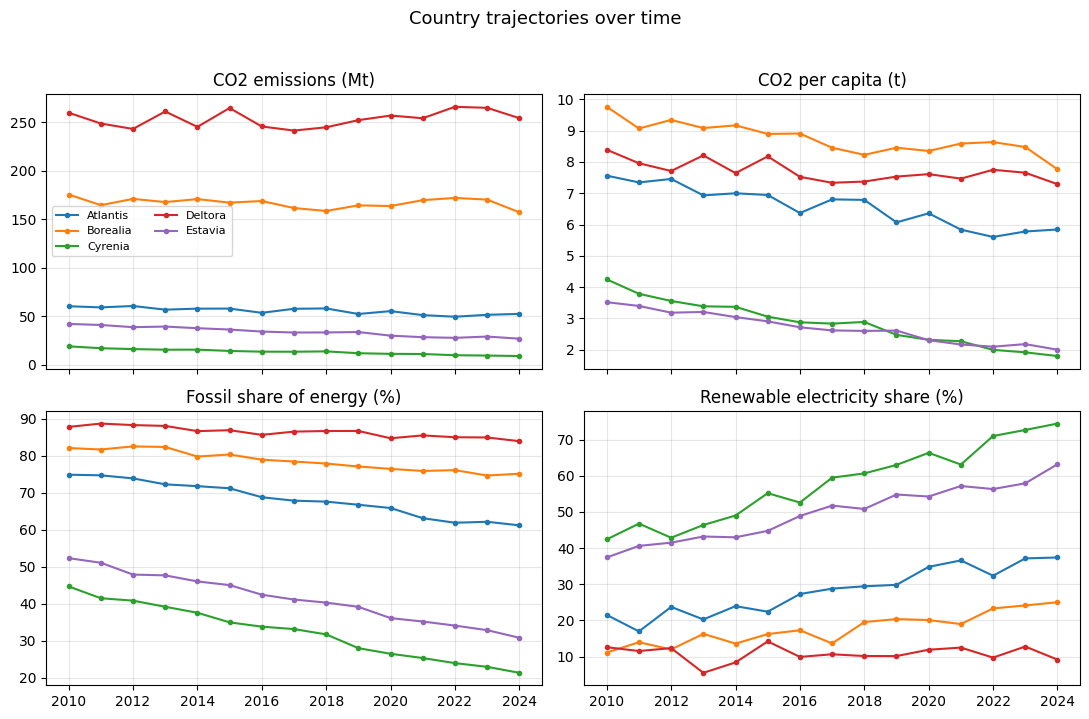

In [4]:
metrics = [
    ('co2', 'CO2 emissions (Mt)'),
    ('co2_per_capita', 'CO2 per capita (t)'),
    ('fossil_share_energy', 'Fossil share of energy (%)'),
    ('renewables_share_elec', 'Renewable electricity share (%)'),
]
fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True)
for ax, (col, label) in zip(axes.ravel(), metrics, strict=False):
    for country, grp in panel.groupby('country'):
        ax.plot(grp['year'], grp[col], marker='.', label=country)
    ax.set_title(label)
    ax.grid(alpha=0.3)
axes[0, 0].legend(fontsize=8, ncol=2)
fig.suptitle('Country trajectories over time', y=1.02, fontsize=13)
fig.tight_layout()
plt.show()

## 2. Distributions

Pooling all country-years, what does each metric's spread look like?

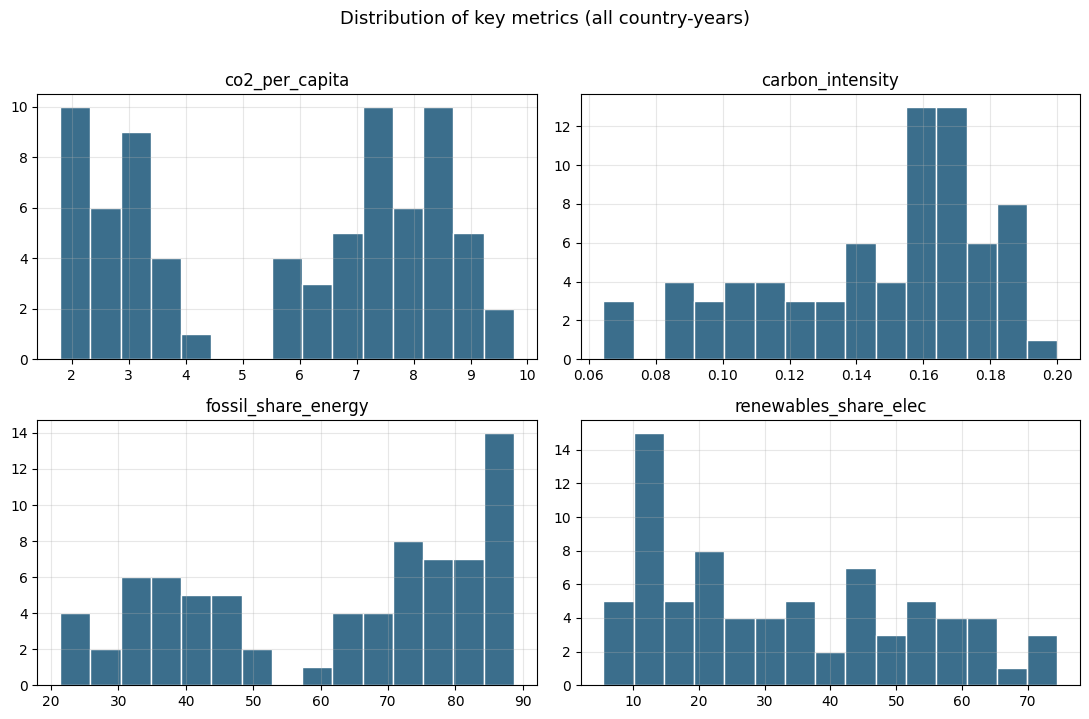

In [5]:
dist_cols = ['co2_per_capita', 'carbon_intensity', 'fossil_share_energy',
             'renewables_share_elec']
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, col in zip(axes.ravel(), dist_cols, strict=False):
    ax.hist(panel[col].dropna(), bins=15, color='#3b6e8c', edgecolor='white')
    ax.set_title(col)
    ax.grid(alpha=0.3)
fig.suptitle('Distribution of key metrics (all country-years)', y=1.02, fontsize=13)
fig.tight_layout()
plt.show()

## 3. Correlations

Which metrics move together? Strong correlations warn that the score components may be partly redundant.

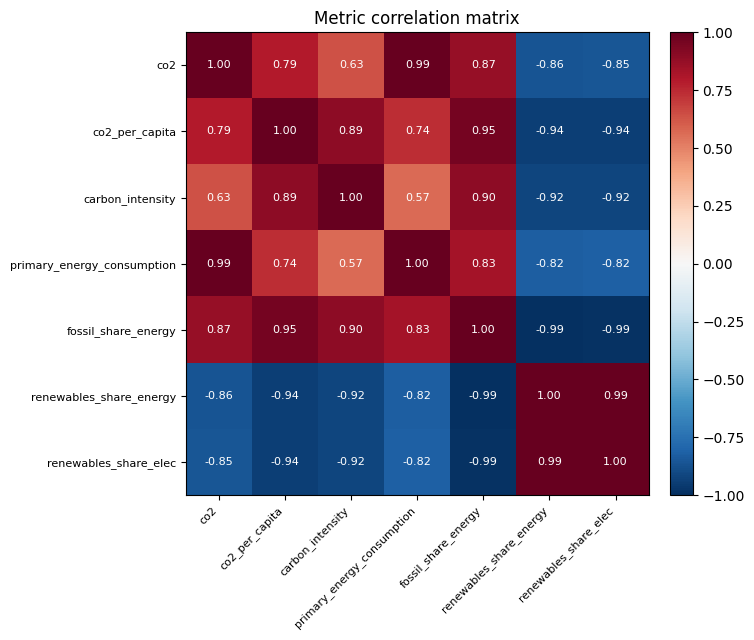

In [6]:
corr_cols = ['co2', 'co2_per_capita', 'carbon_intensity', 'primary_energy_consumption',
             'fossil_share_energy', 'renewables_share_energy', 'renewables_share_elec']
corr = panel[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(corr_cols)))
ax.set_yticklabels(corr_cols, fontsize=8)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center',
                color='white' if abs(corr.iloc[i, j]) > 0.5 else 'black', fontsize=8)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title('Metric correlation matrix')
fig.tight_layout()
plt.show()

## 4. Fossil dependence vs. renewable electricity

The transition story in two dimensions — points drift toward the lower-right (less fossil, more renewable) over time.

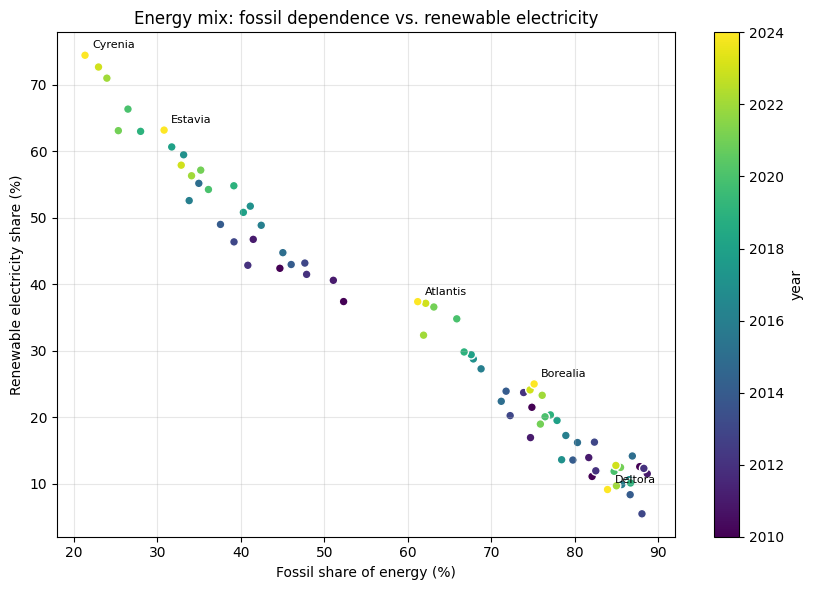

In [7]:
fig, ax = plt.subplots(figsize=(8.5, 6))
sc = ax.scatter(panel['fossil_share_energy'], panel['renewables_share_elec'],
                c=panel['year'], cmap='viridis', s=40, edgecolor='white')
for country, grp in panel.groupby('country'):
    last = grp.sort_values('year').iloc[-1]
    ax.annotate(country, (last['fossil_share_energy'], last['renewables_share_elec']),
                xytext=(5, 5), textcoords='offset points', fontsize=8)
ax.set_xlabel('Fossil share of energy (%)')
ax.set_ylabel('Renewable electricity share (%)')
ax.set_title('Energy mix: fossil dependence vs. renewable electricity')
fig.colorbar(sc, ax=ax, label='year')
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## Takeaways

- The synthetic countries show a deliberate transition: fossil share trends down and renewable electricity trends up over the panel.
- `co2` and `primary_energy_consumption` are strongly correlated — expected, since emissions track energy use in this data.
- Always pair the score with the raw trajectories: a falling score can come from a real transition *or* from a data gap.